In [44]:
# блок подключения доп.библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
# загрузка первичных данных, анализ на наличие пропусков
primary_data = pd.read_csv('../data/logs_exp.csv', sep='\t')
# есть ли пустые значения
#primary_data.info() # или
if primary_data.isna().any().any():
    print("В файле есть null значения. Нужно принять решение, что делать с этими данными")
#primary_data.head(3)

In [66]:
# преобразование данных для удобства работы
data = primary_data.copy()
data['datetime'] = pd.to_datetime(data['EventTimestamp'], unit='s')
data['date'] = data['datetime'].dt.date
#data.head()

data = data.drop('EventTimestamp', axis = 1)
#data.columns = ['event', 'user_id', 'group', 'datetime', 'date']

In [67]:
# Первичный анализ данных
def common_features(data):
    total_events = len(data)
    total_users = data['DeviceIDHash'].nunique()
    period = max(data['datetime']) - min(data['datetime'])

    print(f'Количество событий в логе - {total_events}')
    print(f'Уникальных пользователей - {total_users}')
    print(f'Среднее количество событий на одного пользователя за период анализа - {round(total_events/total_users, 1)}')
    print(f'Среднее количество событий на одного пользователя в день - {round(total_events/total_users/(period.total_seconds()/3600/24), 1)}')
    print(f'''Минимальная дата в логе {min(data['datetime'])}, максимальная дата - {max(data['datetime'])}
Период логирования: {(period)}''')


common_features(data)
#data.groupby('DeviceIDHash').agg(cnt_gr = ('ExpId', 'nunique')).query('cnt_gr >1') # проверил есть ли пользователи в разных группах

Количество событий в логе - 244126
Уникальных пользователей - 7551
Среднее количество событий на одного пользователя за период анализа - 32.3
Среднее количество событий на одного пользователя в день - 2.4
Минимальная дата в логе 2019-07-25 04:43:36, максимальная дата - 2019-08-07 21:15:17
Период логирования: 13 days 16:31:41


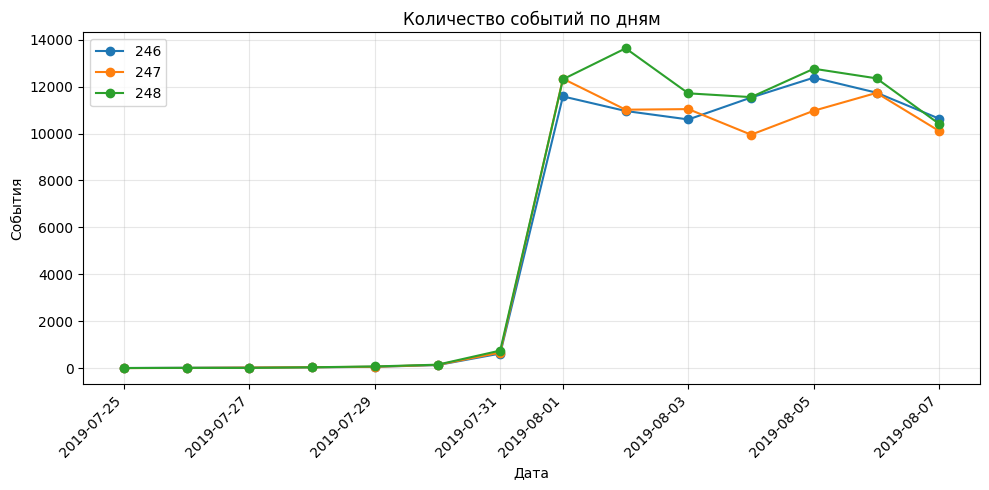

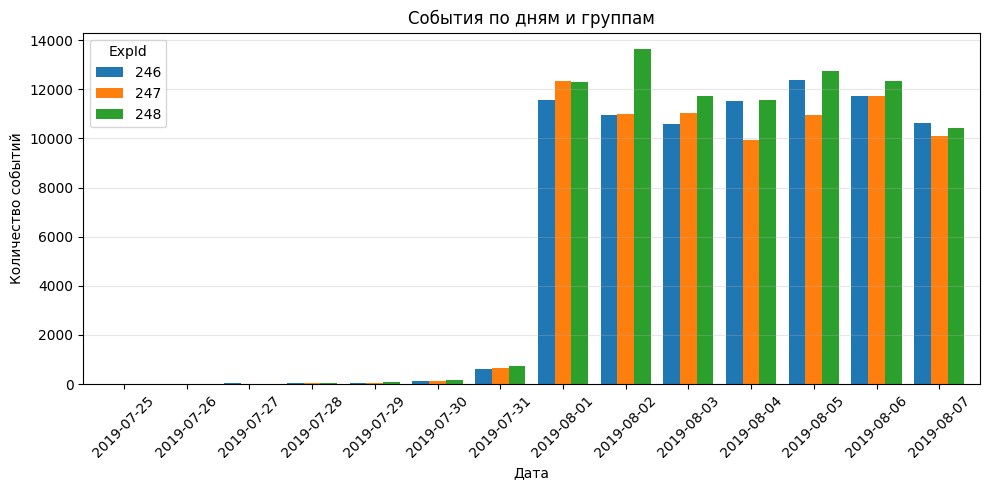

In [68]:
df = data.groupby(['ExpId', 'date']).agg(cnt_events = ('EventName', 'count'), cnt_users = ('DeviceIDHash', 'nunique')).reset_index()
df = df.sort_values(['ExpId', 'date'])

# Анализ данных через линейный график (количество событий)
plt.figure(figsize=(10,5))
for exp_id in df['ExpId'].unique():
    df_exp = df[df['ExpId'] == exp_id]
    plt.plot(df_exp['date'],df_exp['cnt_events'], marker='o', label = exp_id)
plt.title('Количество событий по дням')
plt.xlabel('Дата')
plt.ylabel('События')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Анализ данных через столбчатую диаграмму (количество событий)
plt.figure(figsize=(10, 5))
df_pivot = df.pivot(index = 'date', columns = 'ExpId', values = 'cnt_events')
df_pivot.plot(kind='bar', width=0.8, ax=plt.gca())

plt.title('События по дням и группам')
plt.xlabel('Дата')
plt.ylabel('Количество событий')
plt.legend(title='ExpId')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [69]:
start_log = pd.to_datetime('2019-08-01')
data_clean = data[data['datetime'] >= start_log]
common_features(data_clean)
data_clean.to_csv('../data/clean_data.csv', index=False)

Количество событий в логе - 241298
Уникальных пользователей - 7534
Среднее количество событий на одного пользователя за период анализа - 32.0
Среднее количество событий на одного пользователя в день - 4.7
Минимальная дата в логе 2019-08-01 00:07:28, максимальная дата - 2019-08-07 21:15:17
Период логирования: 6 days 21:07:49
